In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as mnso
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from category_encoders import BinaryEncoder

In [3]:
df = pd.read_csv('nairobi_house_prices.csv')
df.head(10)

,Price,propertyType,Location,Bedroom,bathroom,House size,Land size
0,KSh 350 000 000,Townhouse,Runda,4.0,4.0,NaN,0.5 acres
1,KSh 30 000 000,Vacant Land,Karen,NaN,NaN,NaN,0.5 acres
2,KSh 325 000 000,Vacant Land,Westlands,NaN,NaN,NaN,0.5 acres
3,KSh 80 000 000,Townhouse,Kitisuru,5.0,5.0,NaN,0.5 acres
4,KSh 25 500 000,Apartment,Kileleshwa,4.0,4.0,230 m²,NaN
5,KSh 300 000 000,Townhuse,Runda,6.0,6.0,NaN,0.5 acres
6,KSh 160 000 000,Townhouse,Runda,4.0,4.0,NaN,0.5 acres
7,KSh 9 500 000,Apartment,Kilimani,2.0,2.0,105 m²,NaN
8,KSh 150 000 000,Townhouse,Thigiri,4.0,4.0,NaN,0.5 acres
9,KSh 42 000 000,Apartment,Kileleshwa,4.0,4.0,280 m²,NaN


In [4]:
df['House size'] = df['House size'].str.extract(r'(\d+\.?\d*)').astype(float)
df['Land size'] = df['Land size'].str.replace(' acres', '', regex=False).astype(float)

df['Price'] = df['Price'].astype(str).str.replace(r'[^\d.]', '', regex=True).astype(float)

In [5]:
df.rename(columns={'House size': 'House size (m²)',
                   'Land size':'Land size (acres)',
                   'Price':'Price (Ksh)'}, inplace=True) 

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Price (Ksh)        204 non-null    float64
 1   propertyType       204 non-null    str    
 2   Location           204 non-null    str    
 3   Bedroom            183 non-null    float64
 4   bathroom           181 non-null    float64
 5   House size (m²)    99 non-null     float64
 6   Land size (acres)  64 non-null     float64
dtypes: float64(5), str(2)
memory usage: 11.3 KB


In [7]:
numeric_cols = df.select_dtypes(include = ['float64']).columns
print(numeric_cols)

Index(['Price (Ksh)', 'Bedroom', 'bathroom', 'House size (m²)',
       'Land size (acres)'],
      dtype='str')


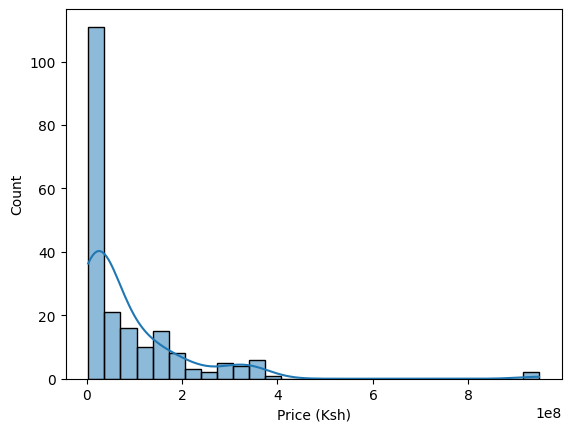

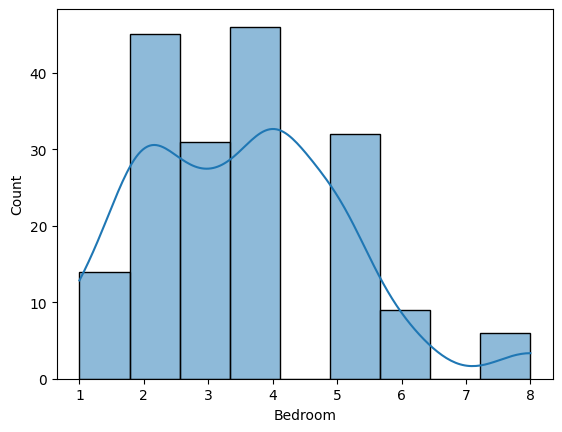

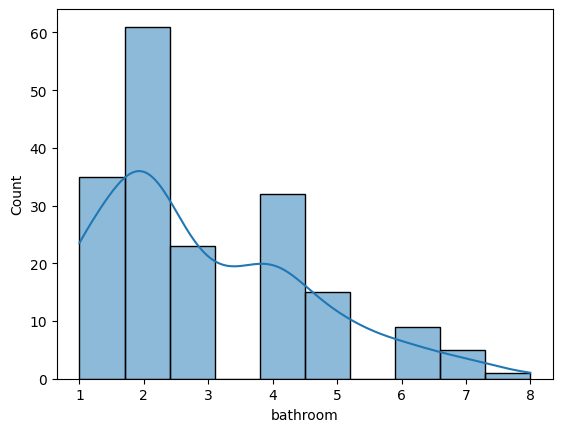

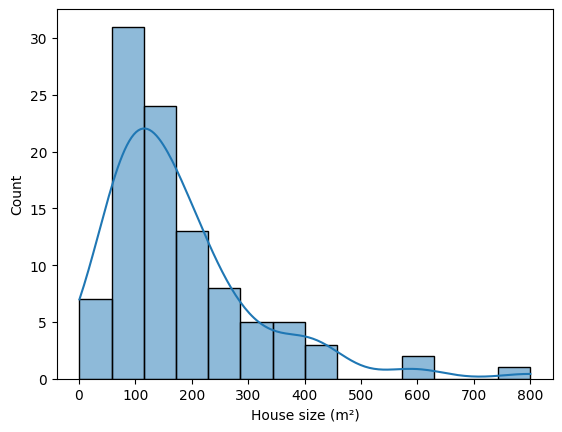

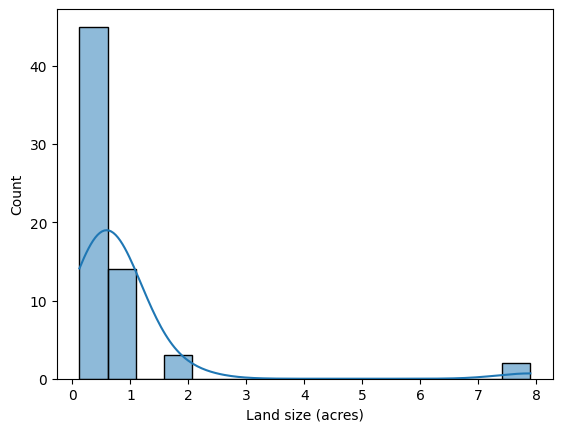

In [8]:
for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde = True)
    plt.show()

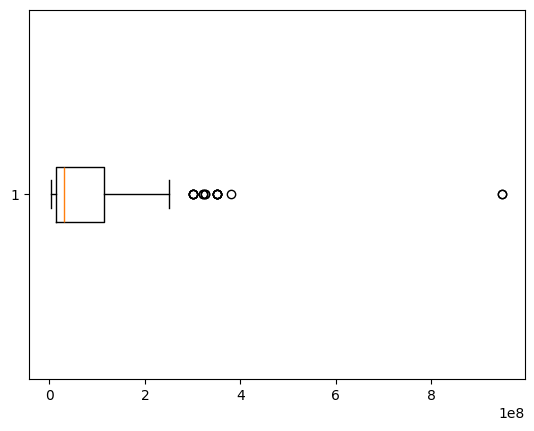

In [9]:
plt.boxplot(df['Price (Ksh)'], vert = False)
plt.show()

In [10]:
Q1 = df['Price (Ksh)'].quantile(0.25)
Q3 = df['Price (Ksh)'].quantile(0.75)

IQR = Q3 - Q1

In [11]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [12]:
df_1 = df[(df['Price (Ksh)'] >= lower_bound) & (df['Price (Ksh)'] <= upper_bound)]

In [13]:
df_1.isnull().sum()

Price (Ksh)            0
propertyType           0
Location               0
Bedroom               15
bathroom              17
House size (m²)       89
Land size (acres)    136
dtype: int64

In [14]:
df_1.drop(columns = ['House size (m²)', 'Land size (acres)'], inplace = True)

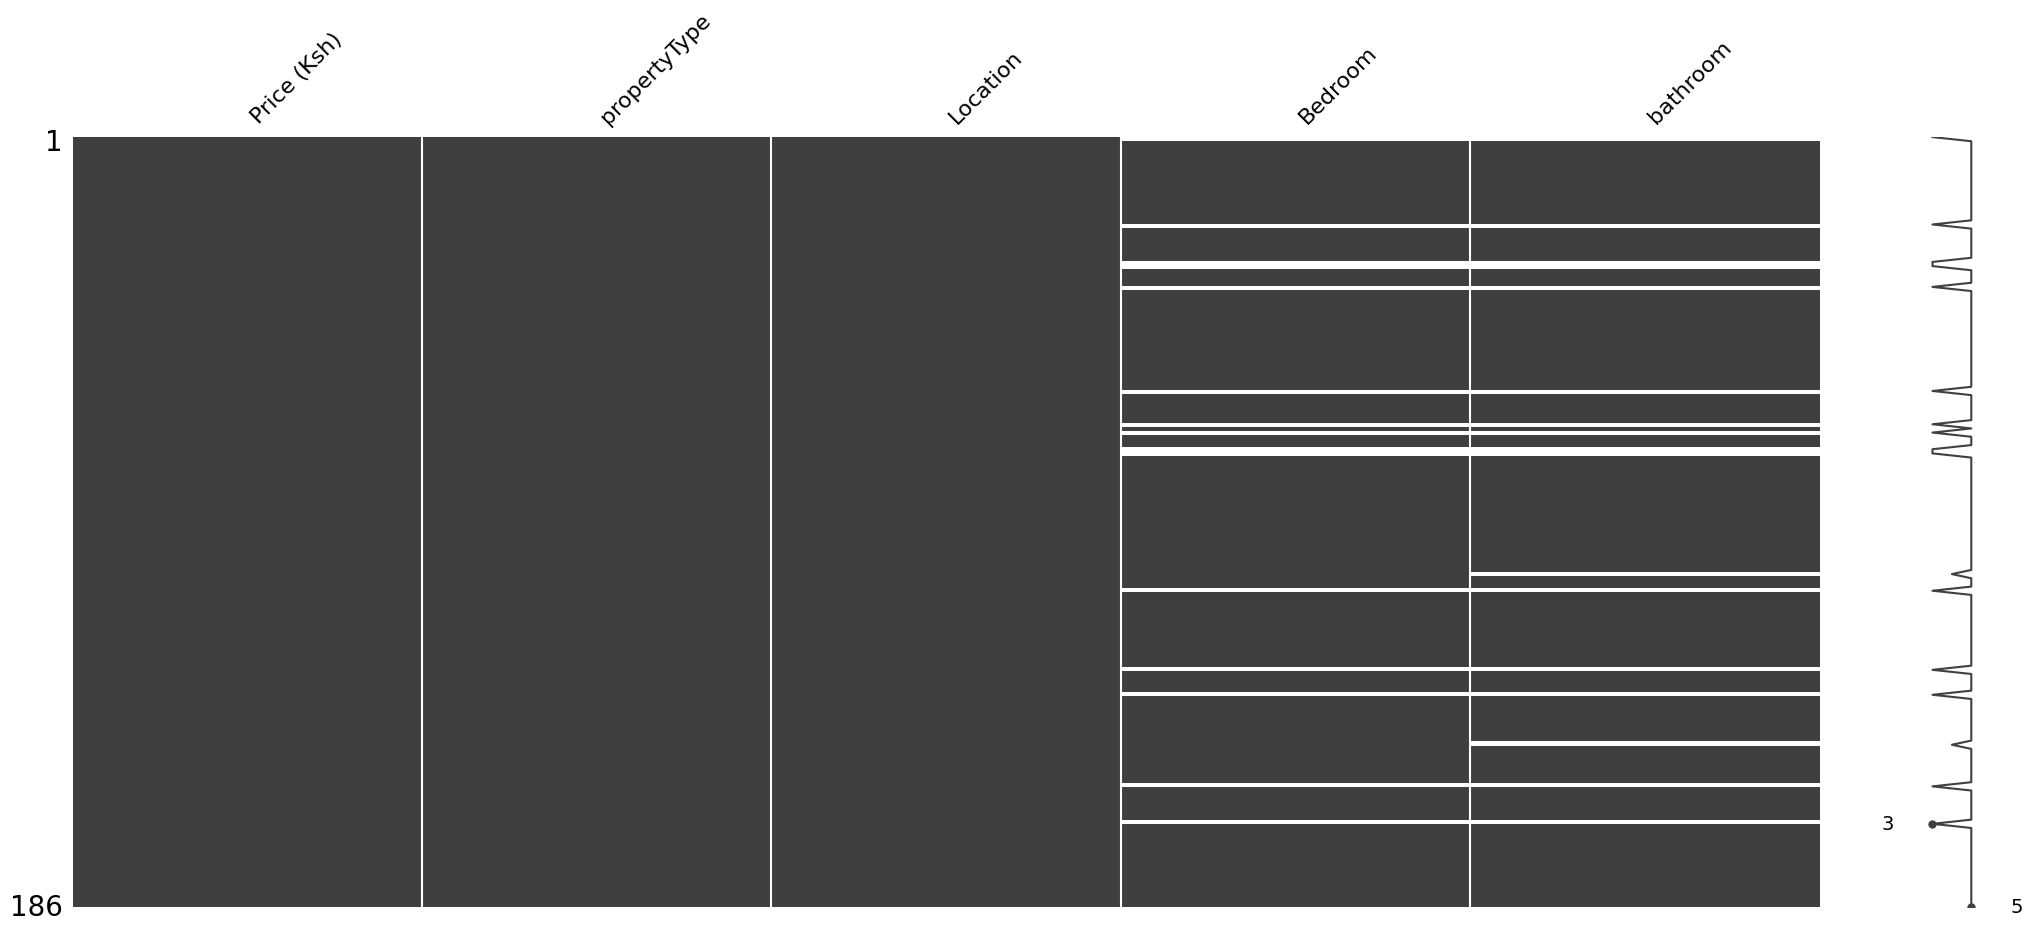

In [15]:
mnso.matrix(df_1)
plt.show()

In [16]:
df_1['Bedroom'] = df_1['Bedroom'].fillna(df_1['Bedroom'].median())
df_1['bathroom'] = df_1['bathroom'].fillna(df_1['bathroom'].median())

In [17]:
#df['House size (m²)'] = df['House size (m²)'].fillna(df['House size (m²)'].median())
#df['Land size (acres)'] = df['Land size (acres)'].fillna(df['Land size (acres)'].median())

In [18]:
df_1.isnull().sum()

Price (Ksh)     0
propertyType    0
Location        0
Bedroom         0
bathroom        0
dtype: int64

In [19]:
df_1.tail()

,Price (Ksh),propertyType,Location,Bedroom,bathroom
199,6000000.0,Apartment,Westlands,1.0,1.0
200,200000000.0,Townhouse,Runda,8.0,7.0
201,9500000.0,Apartment,Nairobi West,2.0,2.0
202,12500000.0,Apartment,Kilimani,2.0,1.0
203,28000000.0,Townhouse,Kiambu Road,4.0,3.0


In [20]:
encoder = BinaryEncoder(cols=['propertyType','Location'])
encoded_data = encoder.fit_transform(df_1)

In [21]:
encoded_data

,Price (Ksh),propertyType_0,propertyType_1,propertyType_2,Location_0,Location_1,Location_2,Location_3,Location_4,Bedroom,bathroom
1,30000000.0,0,0,1,0,0,0,0,1,3.0,2.0
3,80000000.0,0,1,0,0,0,0,1,0,5.0,5.0
4,25500000.0,0,1,1,0,0,0,1,1,4.0,4.0
6,160000000.0,0,1,0,0,0,1,0,0,4.0,4.0
7,9500000.0,0,1,1,0,0,1,0,1,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...
199,6000000.0,0,1,1,0,1,0,1,0,1.0,1.0
200,200000000.0,0,1,0,0,0,1,0,0,8.0,7.0
201,9500000.0,0,1,1,1,0,1,1,0,2.0,2.0
202,12500000.0,0,1,1,0,0,1,0,1,2.0,1.0


In [22]:
features = ['bathroom']
X = encoded_data[features]
y = encoded_data['Price (Ksh)']

In [23]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [24]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
y_pred = model.predict(X_test)

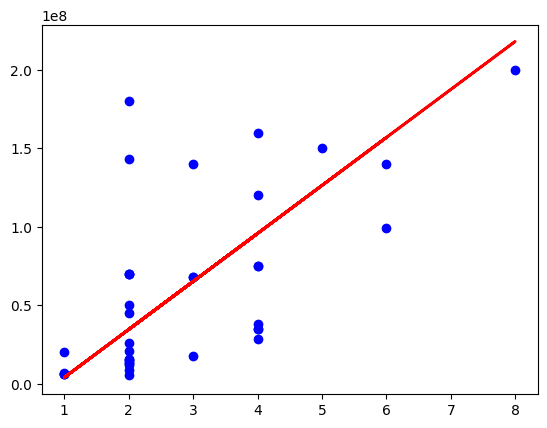

In [ ]:
plt.scatter(X_test,y_test,color = 'blue',label = 'Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted')